# LIBERO CSV解析ノートブック（20Hz・1/3/5/10steps 比較）

このノートブックでは、次の4条件の `task_log.csv` / `episode_log.csv` をまとめて読み込み、
成功率・ステップ数・レイテンシを横断的に集計します。

- `/work/csv/libero/20Hz-1steps`
- `/work/csv/libero/20Hz-3steps`
- `/work/csv/libero/20Hz-5steps (default)`
- `/work/csv/libero/20Hz-10steps`

## 使い方

1. 上から順番にセルを実行してください。
2. `TARGET_CONDITIONS` を変更すると比較対象を追加/削除できます。
3. 最後のセルで suite_summary をCSVにエクスポートできます。

In [69]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

## 1. データ収集
`ROOT_DIR` と `TARGET_CONDITIONS` で対象を指定し、`episode_log.csv` と `task_log.csv` を再帰収集します。
`tmp` を含むパスは除外されるため、一時ファイルの混入を防げます。

In [70]:
ROOT_DIR = Path('/work/csv/libero/20Hz/')
CONTROL_FREQ_HZ = 20
TARGET_CONDITIONS = [
    '1steps',
    '3steps',
    '5steps (default)',
    '10steps',
]

def is_not_tmp(path: Path) -> bool:
    # どの階層でも tmp ディレクトリ配下は除外
    return 'tmp' not in {part.lower() for part in path.parts}

task_log_paths = []
episode_log_paths = []

for cond in TARGET_CONDITIONS:
    cond_dir = ROOT_DIR / cond
    all_task_paths = sorted(cond_dir.glob('**/task_log.csv'))
    all_episode_paths = sorted(cond_dir.glob('**/episode_log.csv'))

    task_paths = [p for p in all_task_paths if is_not_tmp(p)]
    episode_paths = [p for p in all_episode_paths if is_not_tmp(p)]

    task_log_paths.extend(task_paths)
    episode_log_paths.extend(episode_paths)

    excluded_task = len(all_task_paths) - len(task_paths)
    excluded_episode = len(all_episode_paths) - len(episode_paths)
    print(
        f'[{cond}] task_log: {len(task_paths)} (tmp除外 {excluded_task}) / '
        f'episode_log: {len(episode_paths)} (tmp除外 {excluded_episode})'
    )

print(f'対象ルート: {ROOT_DIR}')
print(f'合計 task_log.csv 件数: {len(task_log_paths)}')
print(f'合計 episode_log.csv 件数: {len(episode_log_paths)}')

task_log_paths[:5], episode_log_paths[:5]

[1steps] task_log: 4 (tmp除外 0) / episode_log: 4 (tmp除外 0)
[3steps] task_log: 4 (tmp除外 0) / episode_log: 4 (tmp除外 0)
[5steps (default)] task_log: 4 (tmp除外 1) / episode_log: 4 (tmp除外 1)
[10steps] task_log: 4 (tmp除外 0) / episode_log: 4 (tmp除外 0)
対象ルート: /work/csv/libero/20Hz
合計 task_log.csv 件数: 16
合計 episode_log.csv 件数: 16


([PosixPath('/work/csv/libero/20Hz/1steps/libero_10/2026-04-22_14-08-18/2026-04-23_03-52-36/task_log.csv'),
  PosixPath('/work/csv/libero/20Hz/1steps/libero_goal/2026-04-22_14-08-18/2026-04-23_01-41-47/task_log.csv'),
  PosixPath('/work/csv/libero/20Hz/1steps/libero_object/2026-04-22_14-08-18/2026-04-22_23-08-26/task_log.csv'),
  PosixPath('/work/csv/libero/20Hz/1steps/libero_spatial/2026-04-22_05-28-51/2026-04-22_14-28-53/task_log.csv'),
  PosixPath('/work/csv/libero/20Hz/3steps/libero_10/2026-04-21_01-23-26/2026-04-21_13-35-57/task_log.csv')],
 [PosixPath('/work/csv/libero/20Hz/1steps/libero_10/2026-04-22_14-08-18/2026-04-23_03-52-36/episode_log.csv'),
  PosixPath('/work/csv/libero/20Hz/1steps/libero_goal/2026-04-22_14-08-18/2026-04-23_01-41-47/episode_log.csv'),
  PosixPath('/work/csv/libero/20Hz/1steps/libero_object/2026-04-22_14-08-18/2026-04-22_23-08-26/episode_log.csv'),
  PosixPath('/work/csv/libero/20Hz/1steps/libero_spatial/2026-04-22_05-28-51/2026-04-22_14-28-53/episode_log.

In [71]:
def path_meta(csv_path: Path, root_dir: Path) -> dict:
    rel = csv_path.relative_to(root_dir)
    parts = rel.parts

    # 想定パス: <condition>/<suite>/<run_id>/<file>
    condition = parts[0] if len(parts) >= 1 else 'unknown'
    suite = parts[1] if len(parts) >= 2 else 'unknown'
    run_id = parts[2] if len(parts) >= 3 else 'unknown'

    return {
        'condition': condition,
        'suite': suite,
        'run_id': run_id,
        'source_file': str(csv_path),
    }

def load_many(csv_paths, root_dir: Path):
    frames = []
    for p in csv_paths:
        try:
            df = pd.read_csv(p)
            meta = path_meta(p, root_dir)
            for k, v in meta.items():
                df[k] = v
            frames.append(df)
        except Exception as e:
            print(f'[警告] 読み込みに失敗: {p}: {e}')

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

task_df = load_many(task_log_paths, ROOT_DIR)
episode_df = load_many(episode_log_paths, ROOT_DIR)

## 2. 前処理
読み込んだCSVに対して、`success` の 0/1 正規化と数値列への型変換を行います。
この処理により、条件間比較や統計計算での欠損・型不整合を減らします。

In [72]:
if not episode_df.empty and 'success' in episode_df.columns:
    # success列を 0/1 の数値へ正規化
    episode_df['success'] = episode_df['success'].astype(str).str.lower().map({
        'true': 1, 'false': 0, '1': 1, '0': 0
    }).fillna(0).astype(int)

if not episode_df.empty and 'steps' in episode_df.columns:
    episode_df['steps'] = pd.to_numeric(episode_df['steps'], errors='coerce')

if not episode_df.empty and 'avg_latency_ms' in episode_df.columns:
    episode_df['avg_latency_ms'] = pd.to_numeric(episode_df['avg_latency_ms'], errors='coerce')

if not task_df.empty:
    for col in ['success_rate', 'steps_mean', 'steps_std', 'latency_mean_ms', 'latency_std_ms']:
        if col in task_df.columns:
            task_df[col] = pd.to_numeric(task_df[col], errors='coerce')

In [73]:
# スイート別の集計（平均値 + 標準偏差）
if not episode_df.empty:
    by_suite = (
        episode_df.groupby(['condition', 'suite'], as_index=False)
        .agg(
            episodes=('episode_idx', 'count'),
            success_rate_mean=('success', 'mean'),
            success_rate_std=('success', 'std'),
            steps_mean=('steps', 'mean'),
            steps_std=('steps', 'std'),
            latency_mean_ms=('avg_latency_ms', 'mean'),
            latency_std_ms=('avg_latency_ms', 'std'),
        )
        .sort_values(['condition', 'success_rate_mean'], ascending=[True, False])
    )

    # 標準偏差はサンプル数が1だと NaN になるため 0 で埋める
    for c in ['success_rate_std', 'steps_std', 'latency_std_ms']:
        by_suite[c] = by_suite[c].fillna(0.0)

    # condition 文字列から replan step 数を抽出（例: 20Hz-5steps）
    by_suite['replan_steps'] = by_suite['condition'].str.extract(r'(\d+)steps').astype(float)
    by_suite = by_suite.sort_values(['suite', 'replan_steps'])

    # suite × replan_steps で比較しやすい表を作成（mean / std）
    success_mean_pivot = by_suite.pivot_table(index='suite', columns='replan_steps', values='success_rate_mean')
    success_std_pivot = by_suite.pivot_table(index='suite', columns='replan_steps', values='success_rate_std')

    steps_mean_pivot = by_suite.pivot_table(index='suite', columns='replan_steps', values='steps_mean')
    steps_std_pivot = by_suite.pivot_table(index='suite', columns='replan_steps', values='steps_std')

    latency_mean_pivot = by_suite.pivot_table(index='suite', columns='replan_steps', values='latency_mean_ms')
    latency_std_pivot = by_suite.pivot_table(index='suite', columns='replan_steps', values='latency_std_ms')

    for df_name in [
        'success_mean_pivot', 'success_std_pivot',
        'steps_mean_pivot', 'steps_std_pivot',
        'latency_mean_pivot', 'latency_std_pivot',
    ]:
        locals()[df_name] = locals()[df_name].reindex(sorted(locals()[df_name].columns), axis=1)

    print('suite × step 比較表（成功率: 平均）')
    display(success_mean_pivot)
    print('suite × step 比較表（成功率: 標準偏差）')
    display(success_std_pivot)

    print('suite × step 比較表（ステップ数: 平均）')
    display(steps_mean_pivot)
    print('suite × step 比較表（ステップ数: 標準偏差）')
    display(steps_std_pivot)

    print('suite × step 比較表（平均レイテンシ ms: 平均）')
    display(latency_mean_pivot)
    print('suite × step 比較表（平均レイテンシ ms: 標準偏差）')
    display(latency_std_pivot)
else:
    by_suite = pd.DataFrame()
    success_mean_pivot = pd.DataFrame()
    success_std_pivot = pd.DataFrame()
    steps_mean_pivot = pd.DataFrame()
    steps_std_pivot = pd.DataFrame()
    latency_mean_pivot = pd.DataFrame()
    latency_std_pivot = pd.DataFrame()

by_suite

suite × step 比較表（成功率: 平均）


replan_steps,1.0,3.0,5.0,10.0
suite,,,,
libero_10,0.834,0.908,0.938,0.946
libero_goal,0.920,0.974,0.966,0.982
libero_object,0.928,0.980,0.980,0.992
libero_spatial,0.974,0.988,0.986,0.978


suite × step 比較表（成功率: 標準偏差）


replan_steps,1.0,3.0,5.0,10.0
suite,,,,
libero_10,0.372453,0.289315,0.241397,0.226244
libero_goal,0.271565,0.159295,0.181411,0.133084
libero_object,0.258747,0.140140,0.140140,0.089173
libero_spatial,0.159295,0.108994,0.117608,0.146830


suite × step 比較表（ステップ数: 平均）


...

suite × step 比較表（平均レイテンシ ms: 平均）


replan_steps,1.0,3.0,5.0,10.0
suite,,,,
libero_10,83.141056,83.542020,83.522485,80.936419
libero_goal,84.086203,85.934808,81.124263,80.030097
libero_object,82.011798,82.075893,81.166500,80.208287
libero_spatial,82.231749,81.605705,81.956208,81.010871


suite × step 比較表（平均レイテンシ ms: 標準偏差）


replan_steps,1.0,3.0,5.0,10.0
suite,,,,
libero_10,1.139757,1.757029,2.176358,2.244617
libero_goal,0.795369,1.100186,2.372039,2.352201
libero_object,4.354826,2.201828,2.306089,2.241621
libero_spatial,4.944033,2.342609,27.570516,2.692128


,condition,suite,episodes,success_rate_mean,success_rate_std,steps_mean,steps_std,latency_mean_ms,latency_std_ms,replan_steps
4,1steps,libero_10,500,0.834,0.372453,329.412,110.923750,83.141056,1.139757,1.0
8,3steps,libero_10,500,0.908,0.289315,301.374,97.989172,83.542020,1.757029,3.0
12,5steps (default),libero_10,500,0.938,0.241397,282.702,89.172691,83.522485,2.176358,5.0
0,10steps,libero_10,500,0.946,0.226244,276.152,85.145807,80.936419,2.244617,10.0
5,1steps,libero_goal,500,0.920,0.271565,138.570,65.892646,84.086203,0.795369,1.0
9,3steps,libero_goal,500,0.974,0.159295,128.334,52.236728,85.934808,1.100186,3.0
13,5steps (default),libero_goal,500,0.966,0.181411,126.880,52.489350,81.124263,2.372039,5.0
1,10steps,libero_goal,500,0.982,0.133084,122.438,45.057146,80.030097,2.352201,10.0
6,1steps,libero_object,500,0.928,0.258747,170.900,45.645954,82.011798,4.354826,1.0
10,3steps,libero_object,500,0.980,0.140140,156.542,32.193806,82.075893,2.201828,3.0


## 3. 集計と比較
`condition × suite` で平均指標を集計し、`replan_steps` を抽出して比較軸を統一します。
続く表では、`suite × step` の成功率・平均レイテンシを横並びで確認できます。

In [74]:
# 条件別の派生指標（20Hz想定）
def extract_replan_steps(condition: str) -> float:
    m = re.search(r'(\d+)steps', condition)
    return float(m.group(1)) if m else np.nan

if not by_suite.empty:
    tmp_df = by_suite.copy()
    if 'replan_steps' not in tmp_df.columns:
        tmp_df['replan_steps'] = tmp_df['condition'].map(extract_replan_steps)

    by_condition = (
        tmp_df.groupby('condition', as_index=False)
        .agg(
            replan_steps=('replan_steps', 'first'),
            suites=('suite', 'nunique'),
            episodes=('episodes', 'sum'),
            success_rate_mean=('success_rate_mean', 'mean'),
            success_rate_std=('success_rate_mean', 'std'),
            steps_mean=('steps_mean', 'mean'),
            steps_std=('steps_mean', 'std'),
            latency_mean_ms=('latency_mean_ms', 'mean'),
            latency_std_ms=('latency_mean_ms', 'std'),
        )
    )
    for c in ['success_rate_std', 'steps_std', 'latency_std_ms']:
        by_condition[c] = by_condition[c].fillna(0.0)

    by_condition['step_time_ms'] = 1000.0 / CONTROL_FREQ_HZ
    by_condition['replan_interval_ms'] = by_condition['replan_steps'] * by_condition['step_time_ms']
    by_condition['latency_over_replan_ratio'] = by_condition['latency_mean_ms'] / by_condition['replan_interval_ms']
else:
    by_condition = pd.DataFrame()

by_condition.sort_values('replan_steps') if not by_condition.empty else by_condition

,condition,replan_steps,suites,episodes,success_rate_mean,success_rate_std,steps_mean,steps_std,latency_mean_ms,latency_std_ms,step_time_ms,replan_interval_ms,latency_over_replan_ratio
1,1steps,1.0,4,2000,0.9140,0.058401,189.6790,95.513378,82.867701,0.948064,50.0,50.0,1.657354
2,3steps,3.0,4,2000,0.9625,0.036783,175.6955,85.450519,83.289606,1.946743,50.0,150.0,0.555264
3,5steps (default),5.0,4,2000,0.9675,0.021378,169.5760,76.842530,81.942364,1.120748,50.0,250.0,0.327769
0,10steps,10.0,4,2000,0.9745,0.019891,165.2270,75.153272,80.546419,0.499579,50.0,500.0,0.161093


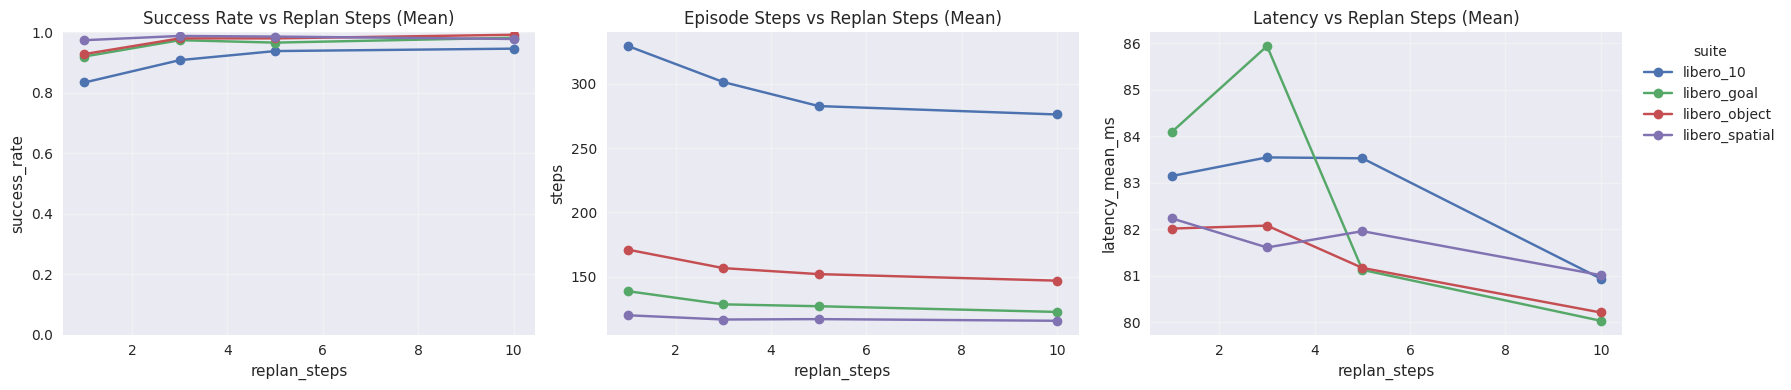

In [75]:
# Plot with plain matplotlib (mean only)
if not by_suite.empty:
    plot_df = by_suite.sort_values(['suite', 'replan_steps'])
    suites = plot_df['suite'].unique()

    plt.figure(figsize=(18, 4))

    plt.subplot(1, 3, 1)
    for suite in suites:
        d = plot_df[plot_df['suite'] == suite]
        plt.plot(
            d['replan_steps'], d['success_rate_mean'],
            marker='o', label=suite
        )
    plt.title('Success Rate vs Replan Steps (Mean)')
    plt.xlabel('replan_steps')
    plt.ylabel('success_rate')
    plt.ylim(0, 1.0)
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    for suite in suites:
        d = plot_df[plot_df['suite'] == suite]
        plt.plot(
            d['replan_steps'], d['steps_mean'],
            marker='o', label=suite
        )
    plt.title('Episode Steps vs Replan Steps (Mean)')
    plt.xlabel('replan_steps')
    plt.ylabel('steps')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    for suite in suites:
        d = plot_df[plot_df['suite'] == suite]
        plt.plot(
            d['replan_steps'], d['latency_mean_ms'],
            marker='o', label=suite
        )
    plt.title('Latency vs Replan Steps (Mean)')
    plt.xlabel('replan_steps')
    plt.ylabel('latency_mean_ms')
    plt.grid(True, alpha=0.3)
    plt.legend(title='suite', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

## 4. 可視化とエクスポート
グラフで step 変化に対する各 suite の傾向を確認し、最後に `suite_summary` をCSVへ書き出します。
出力ファイルは `/work/csv/libero/analysis_exports` に保存されます。

In [76]:
# suite_summary のみ使うため、上位/下位タスク表示はスキップ
print('上位/下位タスク表示はスキップしました（suite_summaryのみ）。')

上位/下位タスク表示はスキップしました（suite_summaryのみ）。


In [77]:
# suite_summary のみCSVで書き出し（20Hz: 1/3/5/10steps 比較）
out_dir = Path('/work/csv/libero/analysis_exports')
out_dir.mkdir(parents=True, exist_ok=True)

if not by_suite.empty:
    out_file = out_dir / 'suite_summary_20Hz_1_3_5_10steps.csv'
    by_suite.to_csv(out_file, index=False)
    print('suite_summary を書き出しました。')
    print(f'書き出し先: {out_file}')
else:
    print('by_suite が空のため、書き出しをスキップしました。')

suite_summary を書き出しました。
書き出し先: /work/csv/libero/analysis_exports/suite_summary_20Hz_1_3_5_10steps.csv
